# ANÁLISE DE DADOS CHINA

# CONFIGURAÇÕES GLOBAIS

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Função utilitária
def truncar(label, max_chars=35):
    return label if len(label) <= max_chars else label[:max_chars] + '...'

# Reseta opções do pandas
pd.reset_option('display.max_rows')

# HOW CHINA LENDS

In [19]:
df = pd.read_excel('data/How_China_Lends_Dataset_Version_2_0.xlsx', sheet_name='ContractData')

print('Shape:', df.shape)
print('\nColunas:')
print(df.columns.tolist())
print('\nValores nulos:')
print(df.isnull().sum())

Shape: (371, 55)

Colunas:
['contract_id', 'AidData_record_ID', 'AidData_parent_ID', 'HCL_sample', 'contract_incomplete', 'contract_incomplete_des', 'contract_language', 'source', 'year', 'creditor_name', 'creditor_type', 'creditor_country', 'borrower_name', 'borrower_type', 'borrower_country', 'borrower_region', 'borrower_income', 'commitment_orig', 'currency', 'fx', 'commitment_USD', 'loan_contract', 'contract_category', 'PPG_debt', 'syndicated_commercial', 'restructuring', 'cofinancing_multilaterals', 'cofinancing_and_syndicated', 'project_title', 'oecd_sector_code', 'guarantor', 'guarantor_name', 'collateral', 'escrow_account', 'reserve_account', 'revenue_account', 'account_des', 'confidentiality_general', 'confidentiality_borrower', 'confidentiality_des_borrower', 'confidentiality_lender', 'confidentiality_des_lender', 'paris_clause', 'paris_clause_des', 'cross_default', 'cross-default_des', 'penalty_interest_rate', 'penalty_interest_rate_des', 'governing_law', 'governing_law_part

### Verificações

In [ ]:
df.head()

In [ ]:
df.describe()

## PREPARANDO OS DADOS ÚTEIS

In [20]:
# Coluna de ano extraída do contract_id
df['year'] = df['contract_id'].str.extract(r'_(\d{4})_').astype(int)
ultimo_ano = df['year'].max()
ultimosanos = df[df['year'] >= ultimo_ano - 13]

# DataFrame com credores separados (explode)
df_credores = df.copy()
df_credores['creditor_name'] = df_credores['creditor_name'].str.split('; ')
df_credores = df_credores.explode('creditor_name')
df_credores['creditor_name'] = df_credores['creditor_name'].str.strip()
df_credores['year'] = df_credores['contract_id'].str.extract(r'_(\d{4})_').astype(int)

# Credores com 5+ contratos
contagem = df_credores['creditor_name'].value_counts()
credores_frequentes = contagem[contagem >= 5].index

# Filtro dos últimos 13 anos para df_credores
ano_credores = df_credores['year'].max()
periodo_max = df_credores[df_credores['year'] >= ano_credores - 13]

print('df original:', df.shape)
print('df_credores (explodido):', df_credores.shape)

df original: (371, 55)
df_credores (explodido): (519, 55)


### Exploração Básica ("setagem" da região)

In [ ]:
df["borrower_country"].value_counts()

regiao = df["borrower_region"].value_counts()
print(regiao)

## Gráficos:

### 10 PAÍSES QUE MAIS RECEBERAM CONTRATOS DE EMPRÉSTIMO

In [ ]:
pais = df["borrower_country"].value_counts().head(10)
print(pais)
pais.plot(kind="bar")
plt.title("Top 10 países com mais contratos")
plt.xlabel("País")
plt.ylabel("Número de contratos")
plt.tight_layout()
plt.show()


### 10 países por valor total (USD) de empréstimos

In [ ]:
top10_geral = (
    df.groupby("borrower_country")["commitment_USD"]
    .sum()
    .sort_values(ascending=False)
    .head(10) / 1e9
)
top10_geral.plot(kind="bar")
plt.title("Top 10 países que mais receberam empréstimos chineses")
plt.ylabel("Bilhões de USD")
plt.xlabel("País")
plt.tight_layout()
print(top10_geral)
plt.show()

### 10 países por valor total (USD) de empréstimos - últimos 13 anos

In [ ]:
top10_recente = (
    ultimosanos.groupby("borrower_country")["commitment_USD"]
    .sum()
    .sort_values(ascending=False)
    .head(10) / 1e9
)
top10_recente.plot(kind="bar")
plt.title("Top 10 países — últimos 13 anos")
plt.ylabel("Bilhões de USD")
plt.xlabel("País")
plt.tight_layout()
print(top10_recente)
plt.show()

### Contrato por região

In [ ]:
regiao.plot(kind="bar")
plt.title("Número de contratos por região")
plt.xlabel("Região")
plt.ylabel("Número de contratos")
plt.tight_layout()
print(regiao)
plt.show()

### Regiões por valor total (USD) de empréstimos - últimos 13 anos

In [ ]:
region = (
    ultimosanos.groupby("borrower_region")["commitment_USD"]
    .sum()
    .sort_values(ascending=False) / 1e9
)
region.plot(kind="bar")
plt.title("Regiões que mais receberam empréstimos chineses — últimos 13 anos")
plt.ylabel("Bilhões de USD")
plt.xlabel("Região")
plt.tight_layout()
print(region)
plt.show()

### América Latina - últimos 13 anos

In [ ]:
latam = ultimosanos[ultimosanos["borrower_region"] == "Latin America and the Caribbean"]
ranking = (
    latam.groupby("borrower_country")["commitment_USD"]
    .sum()
    .sort_values(ascending=False) / 1e9
)

ranking.index.name = "País"
ranking.name = "Empréstimos (bilhões USD)"
ranking.plot(kind="bar")
plt.title("América Latina — empréstimos chineses (últimos 13 anos)")
plt.ylabel("Bilhões de USD")
plt.xlabel("País")
print(ranking)
plt.tight_layout()
plt.show()

### Brasil ao longo do tempo

In [ ]:
brasil = df[df["borrower_country"] == "Brazil"]
(brasil.groupby("year")["commitment_USD"].sum() / 1e9).plot()
plt.title("Empréstimos chineses ao Brasil ao longo do tempo")
plt.ylabel("Bilhões de USD")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()

### O mundo ao longo do tempo

In [ ]:
(df.groupby("year")["commitment_USD"].sum() / 1e9).plot()
plt.title("Empréstimos chineses ao longo do tempo")
plt.ylabel("Bilhões de USD")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()

### 10 credores com maior número de contratos no mundo

In [ ]:
# Top 10 credores por número de contratos
print(contagem.head(10))

# Média por credor (mínimo 5 contratos)
media_por_credor = (
    df_credores[df_credores['creditor_name'].isin(credores_frequentes)]
    .groupby('creditor_name')['commitment_USD']
    .mean()
    .sort_values(ascending=False) / 1e9
).head(10)
print(media_por_credor)

### Os 10 maiores credores - USD


borrower_region                  creditor_name                                         
Latin America and the Caribbean  China Development Bank                                    64.802816
Sub-Saharan Africa               Export-Import Bank of China                               21.325278
Latin America and the Caribbean  Export-Import Bank of China                               20.242242
East Asia and Pacific            China Development Bank                                    15.701000
Latin America and the Caribbean  Bank of China Ltd.                                        14.966808
Europe and Central Asia          Export-Import Bank of China                               10.221181
Middle East and North Africa     China Export & Credit Insurance Corporation (Sinosure)    10.000000
Europe and Central Asia          China Development Bank                                     8.294577
Latin America and the Caribbean  ICBC                                                       7.784811
Nor

C:\Users\nick_\AppData\Local\Temp\ipykernel_11080\1024359716.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


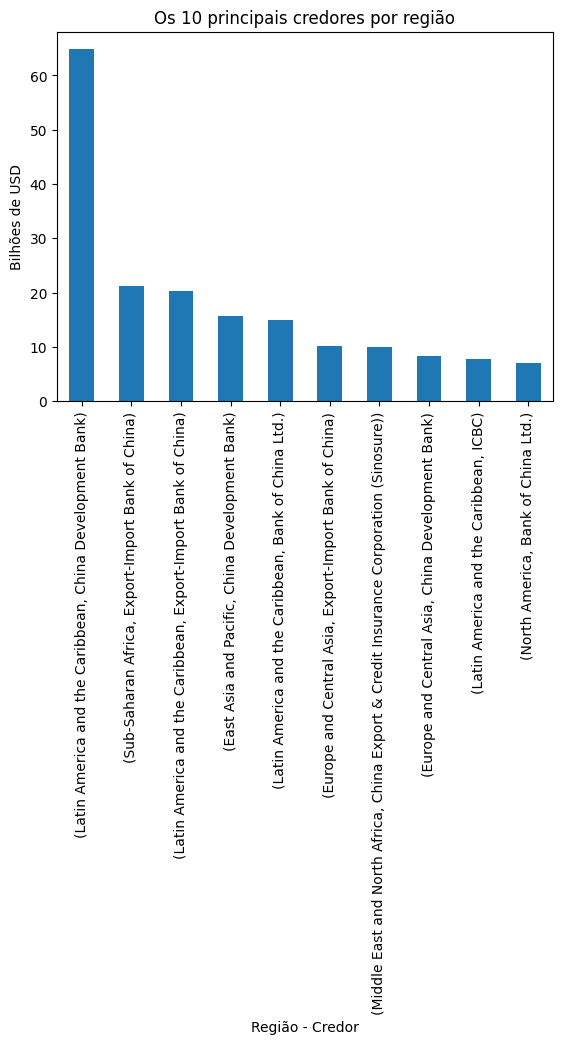

In [23]:
ranking_regiao = (
    df_credores.groupby(["borrower_region", "creditor_name"])["commitment_USD"]
    .sum()
    .sort_values(ascending=False).head(10) / 1e9
)

ranking_regiao.index.name = "Credor"
ranking_regiao.name = "Os 10 principais credores por região"
print(ranking_regiao)

ranking_regiao.plot(kind="bar")
plt.title("Os 10 principais credores por região")
plt.ylabel("Bilhões de USD")
plt.xlabel("Região - Credor")

plt.tight_layout()
plt.show()

### Os 10 maiores credores da América Latina e Caribe

In [ ]:
latamcar_credores = df_credores[df_credores["borrower_region"] =="Latin America and the Caribbean"]

ranking_latamcaribe = (latamcar_credores.groupby("creditor_name")["commitment_USD"].sum().sort_values(ascending=False) / 1e9).head(10)



ranking_latamcaribe.index.name = "Credor"
ranking_latamcaribe.name = " 10 Principais credores da América Latina e Caribe"

print(ranking_latamcaribe)
ranking_latamcaribe.head(10).plot(kind="barh")

ax = plt.gca() # "get current axis" — pega o eixo atual, só funciona dentro de cada bloco de código, não da para setar como variável, eu tentei, ficou ruim

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2, #isso tudo aqui funciona com um barh, para funcionar com um bar normal faça:  bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,  f"{bar.get_height():.1f}", ha='center'
        f"{bar.get_width():.1f}",
        va='center'
    )



plt.title("América Latina e Caribe — 10 maiores credores chineses")
plt.ylabel("Bilhões de USD")
plt.xlabel("Credor")

ax.set_xlim(0, ranking_latamcaribe.max() * 1.15)

ax.set_yticklabels([truncar(t.get_text()) for t in ax.get_yticklabels()]) #truncar gráficos únicos
plt.tight_layout()
plt.show()

### Quantas vezes o China Development Bank aparece em contratos sindicalizados

In [ ]:
cdb_sind = df_credores[
    (df_credores['syndicated_commercial'] == 1) &
    (df_credores['creditor_name'] == 'China Development Bank')
]

df_dolar_cdb = cdb_sind[['borrower_country', 'creditor_name', 'commitment_USD', 'project_title']].copy()
df_dolar_cdb['commitment_USD'] = df_dolar_cdb['commitment_USD'] / 1e9

print('=== Contratos sindicalizados do CDB ===')
print(df_dolar_cdb)
print('\n=== Valor total potencialmente duplicado ===')
print(cdb_sind['commitment_USD'].sum() / 1e9)

### Comparações com subplots

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Gráfico da esquerda
contagem.head(10).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Número de contratos por credor")
axes[0].set_ylabel("")

for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )

# Gráfico da direita
media_por_credor.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Valor médio por contrato (Bilhões USD)")
axes[1].set_ylabel("")  

for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )




axes[0].tick_params(axis='y', labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

### Comparação - últimos 13 anos

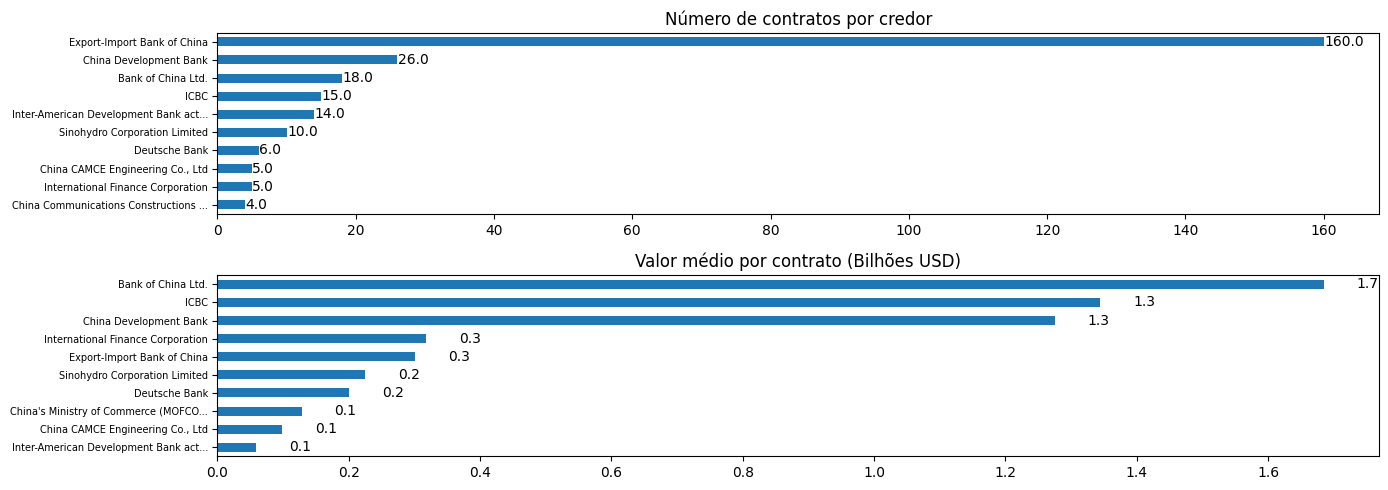

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))


media_contrato_ano = periodo_max["creditor_name"].value_counts().head(10)

media_contrato_ano.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Número de contratos por credor")
axes[0].set_ylabel("")

for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )

media_credores_ano = (
    periodo_max[periodo_max["creditor_name"].isin(credores_frequentes)]
    .groupby("creditor_name")["commitment_USD"]
    .mean()
    .sort_values(ascending=False) / 1e9
).head(10)
media_credores_ano.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Valor médio por contrato (Bilhões USD)")
axes[1].set_ylabel("")

for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )



axes[0].tick_params(axis='y', labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)
axes[0].set_yticklabels([truncar(t.get_text()) for t in axes[0].get_yticklabels()])
axes[1].set_yticklabels([truncar(t.get_text()) for t in axes[1].get_yticklabels()])


plt.tight_layout()
plt.show()

    

# DADOS DO "GLOBAL CHINESE DEVELOPMENT FINANCE"


In [28]:
gcdf = pd.read_excel("data/AidDatasGlobalChineseDevelopmentFinanceDataset_v2.0.xlsx", sheet_name="Global_CDF2.0")

print('Shape:', gcdf.shape)
print('\nPeríodo:', gcdf['Commitment Year'].min(), 'a', gcdf['Commitment Year'].max())

Shape: (13427, 70)

Período: 2000 a 2017


In [ ]:
gcdf.head()

In [ ]:
gcdf.columns.tolist()

### Valores por ano

In [29]:
projetos = gcdf["Commitment Year"].value_counts().sort_index()
print(projetos)

Commitment Year
2000     209
2001     285
2002     318
2003     370
2004     445
2005     599
2006     669
2007     747
2008     658
2009     830
2010     862
2011     982
2012     889
2013     909
2014     994
2015    1121
2016    1187
2017    1353
Name: count, dtype: int64


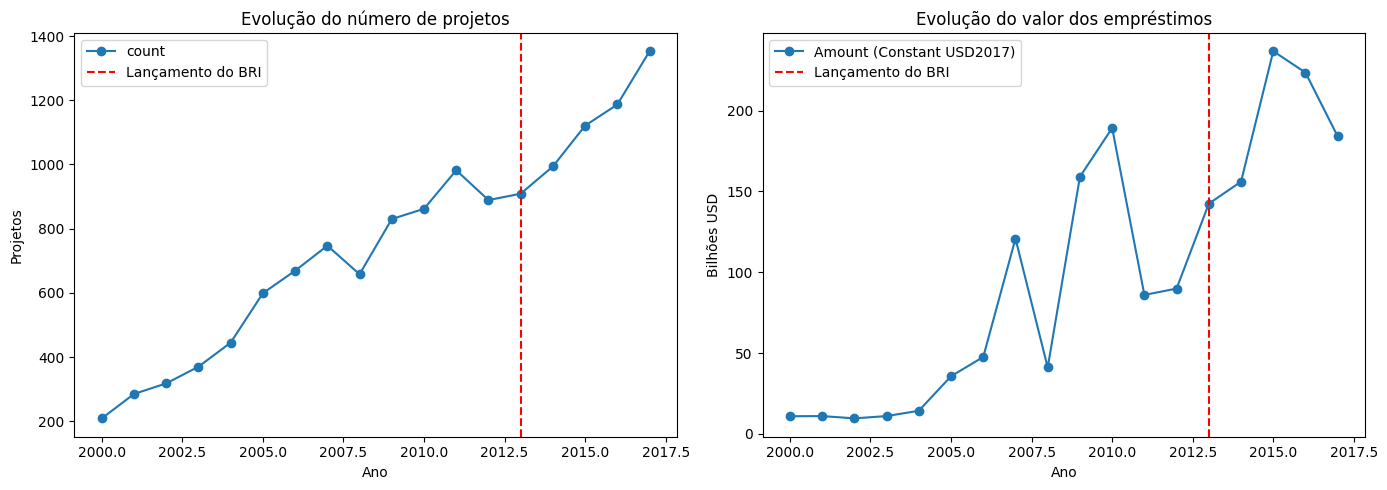

In [31]:
evolucao = gcdf.groupby('Commitment Year')['Amount (Constant USD2017)'].sum().sort_index() / 1e9
projetos = gcdf['Commitment Year'].value_counts().sort_index()

# Subplot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

projetos.plot(kind='line', marker='o', ax=axes[0])
axes[0].set_title('Evolução do número de projetos')
axes[0].set_ylabel('Projetos')
axes[0].set_xlabel('Ano')
axes[0].axvline(x=2013, color='red', linestyle='--', label='Lançamento do BRI')
axes[0].legend()

evolucao.plot(kind='line', marker='o', ax=axes[1])
axes[1].set_title('Evolução do valor dos empréstimos')
axes[1].set_ylabel('Bilhões USD')
axes[1].set_xlabel('Ano')
axes[1].axvline(x=2013, color='red', linestyle='--', label='Lançamento do BRI')
axes[1].legend()

plt.tight_layout()
plt.show()

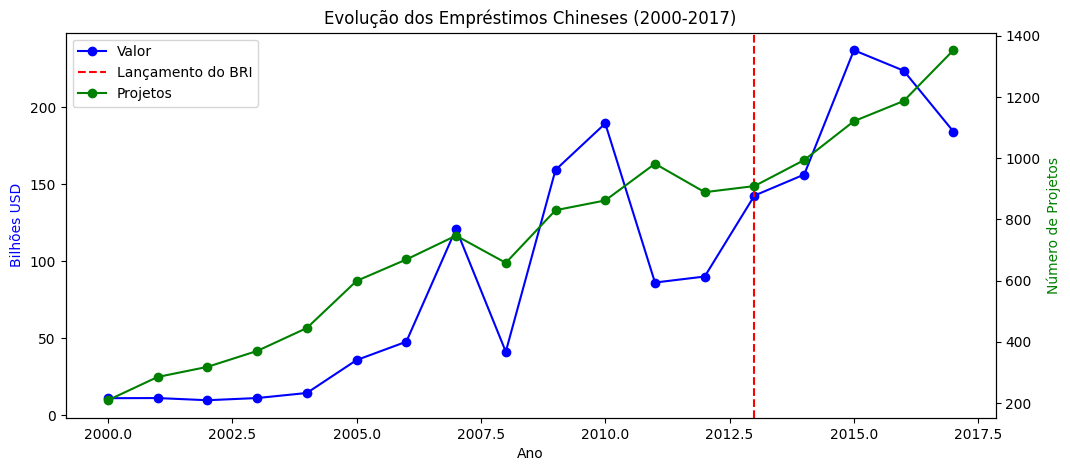

In [32]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()  # cria segundo eixo Y

plt.axvline(x=2013, color="red", linestyle="--", label="Lançamento do BRI")
evolucao.plot(kind="line", marker="o", ax=ax1, color="blue", label="Valor")
projetos.sort_index().plot(kind="line", marker="o", ax=ax2, color="green", label="Projetos")
ax1.set_title("Evolução dos Empréstimos Chineses (2000-2017)")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Bilhões USD", color="blue")
ax2.set_ylabel("Número de Projetos", color="green")
# pega as linhas e labels de cada eixo
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# junta tudo numa legenda só no ax1
ax1.legend(lines1 + lines2, labels1 + labels2)


### Regiões dos Empréstimos

In [33]:
regioes = gcdf["Recipient Region"].value_counts()

regioes.index.name ="Regiões"
regioes.name="Regiões que mais receberam empréstimos"
print(regioes)


Regiões
Africa          6313
Asia            3405
America         1628
Oceania          915
Europe           698
Middle East      434
Multi-Region      34
Name: Regiões que mais receberam empréstimos, dtype: int64


### Valores por região

In [ ]:
valor_regiao = gcdf.groupby("Recipient Region")["Amount (Constant USD2017)"].sum().sort_values(ascending=False) / 1e9
valor_regiao.index.name="Regiões"
valor_regiao.name="Valor por região"
print(valor_regiao)
valor_regiao.plot(kind="bar")
plt.title("Valor por região em Bilhões - USD")
plt.ylabel("Bilhões em USD")
plt.xlabel("Região")
plt.show()

### Subplot dos dados de cima

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

#Gráfico da esquerda - Regiões
regioes.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Regiões")
axes[0].set_xlabel("Número de contratos")
axes[0].set_ylabel("")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )
axes[0].set_xlim(0, regioes.max() * 1.20)

#Gráfico da direita - Valor por região
valor_regiao.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Valor por região")
axes[1].set_xlabel("Bilhões em USD")
axes[1].set_ylabel("")
for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )
axes[1].set_xlim(0, valor_regiao.max() * 1.20)




plt.tight_layout()
plt.show()

### Setores

In [ ]:
setores = gcdf["Sector Name"].value_counts().head(15)

plt.figure(figsize=(10, 15))

ax=plt.gca()

setores.index.name="Setores"
setores.name="Quantidade de Empréstimos por Setor"
print(setores)

setores.plot(kind="bar")

for bar in ax.patches:
    ax.text(
    bar.get_x() + bar.get_width() / 2, 
    bar.get_height() + 0.5,  
    f"{bar.get_height():.1f}", 
    ha='center'
    )

ax.set_ylim(0, setores.max() * 1.15)

ax.set_yticklabels([truncar(t.get_text()) for t in ax.get_yticklabels()])
plt.title("Setores com maiores empréstimos")
plt.ylabel("Quantidade de empréstimos")
plt.xlabel("Setores")
plt.show()

### Valor por setores

In [ ]:
valor_setores = gcdf.groupby("Sector Name")["Amount (Constant USD2017)"].sum().sort_values(ascending=False)/1e9

print(valor_setores)


### O que é "Other Multisector"?

In [ ]:
for texto in gcdf[gcdf["Sector Name"] == "OTHER MULTISECTOR"]["Description"].head(5):
    print(texto)
    print("---")

### Exclusão do "Other Multisector"

In [ ]:
setores_valor = gcdf[gcdf["Sector Name"] != "OTHER MULTISECTOR"].groupby("Sector Name")["Amount (Constant USD2017)"].sum().sort_values(ascending=False).head(10) / 1e9
setores_valor.index.name="Setores Valor"
setores_valor.name="Valor por setores - Bilhão USD"

print(setores_valor)

### Setores por região

In [ ]:
for regiao in gcdf["Recipient Region"].unique():
    dados_regiao = gcdf[
        (gcdf["Recipient Region"] == regiao) &
        (gcdf["Sector Name"] != "OTHER MULTISECTOR")
    ]
    
    resultado = dados_regiao.groupby("Sector Name").agg(
        projetos=("Sector Name", "size"),
        valor=("Amount (Constant USD2017)", "sum")
    ).sort_values("projetos", ascending=False)
    
    resultado["valor"] = resultado["valor"] / 1e9
    pd.set_option("display.max_rows", None)
    print(f"\n{'='*50}")
    print(f"  {regiao}")
    print(f"{'='*50}")
    print(resultado.to_string())


In [ ]:
pivot = gcdf.groupby(["Recipient Region", "Sector Name"]).size().unstack(fill_value=0)
pivot.idxmax(axis=1)
print(pivot)

In [ ]:
setor_regiao = ( 
    gcdf[gcdf["Sector Name"] != "OTHER MULTISECTOR"].groupby(["Recipient Region", "Sector Name"])["Amount (Constant USD2017)"].sum().sort_values(ascending=False).head(10) / 1e9
)
print(setor_regiao)

In [ ]:
setor_regiao_top = (
    gcdf[gcdf["Sector Name"] != "OTHER MULTISECTOR"]
    .groupby(["Recipient Region", "Sector Name"])["Amount (Constant USD2017)"]
    .sum()
    .sort_values(ascending=False)
    / 1e9
)

pd.set_option("display.max_rows", None)


setor_regiao_top.index.name="Setores"
setor_regiao_top.name="Quantidade de Empréstimos por Setor"
print(setor_regiao_top)





In [ ]:
# contagem por região e setor
contagem = (
    gcdf[gcdf["Sector Name"] != "OTHER MULTISECTOR"]
    .groupby(["Recipient Region", "Sector Name"])
    .size()
)

# setor líder de cada região
lider = contagem.groupby("Recipient Region").idxmax().apply(lambda x: x[1])

# valor do setor líder de cada região
valores = contagem.groupby("Recipient Region").max()

print(lider)
print(valores)

In [ ]:
setor_regiao_projetos = (
    gcdf[gcdf["Sector Name"] != "OTHER MULTISECTOR"]
    .groupby(["Recipient Region", "Sector Name"])
    .size()
    .groupby("Recipient Region")
    .idxmax()
    .apply(lambda x: x[1])
)


setor_regiao_projetos.index.name="Setores"
setor_regiao_projetos.name="Quantidade de Empréstimos por Setor"
print(setor_regiao_projetos)

print(setor_regiao_projetos)

In [ ]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

valores.plot(kind="bar", ax=ax)

ax.set_xticklabels([f"{regiao}\n{setor}" for regiao, setor in zip(valores.index, lider)], rotation=45, ha="right")

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.0f}",
        ha='center'
    )

ax.set_ylim(0, valores.max() * 1.15)
plt.title("Setor líder por região (número de projetos)")
plt.ylabel("Número de projetos")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
regioes_lista = gcdf["Recipient Region"].unique()
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
axes = axes.flatten() 

for i, regiao in enumerate(regioes_lista):
    dados_regiao= gcdf[
        (gcdf["Recipient Region"] == regiao) & 
        (gcdf["Sector Name"] != "OTHER MULTISECTOR")
    ]

    setor_valor = (dados_regiao
        .groupby("Sector Name")["Amount (Constant USD2017)"]
        .sum()
        .sort_values(ascending=False) / 1e9
    )
    
    setor_valor.plot(kind="barh", ax=axes[i])
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].set_title(regiao)
    axes[i].set_ylabel("Projetos")
    axes[i].set_xlabel("Setores")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=3.0)

print(regioes_lista)

### Comparação por região e valores

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))



setores.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Setores")
axes[0].set_xlabel("Contrato por setores")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )
axes[0].set_xlim(0, setores.max() * 1.20)
print(setores)
setores.index.name="Setores"
setores.name="Quantidade de Empréstimos por Setor"

setores_valor.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Valor por setor")
axes[1].set_xlabel("Bilhões em USD")
for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )
axes[1].set_xlim(0, setores_valor.max() * 1.20)
print(setores_valor)
setores_valor.index.name="Setores Valor"
setores_valor.name="Valor por setores - Bilhão USD"

plt.tight_layout()
plt.show()


## SEPARAR AS REGIÕES

In [ ]:
for regiao in gcdf["Recipient Region"].unique():
    valor_regiao = gcdf[
        (gcdf["Recipient Region"] == regiao)
    ]
    ranking = valor_regiao.groupby("Recipient")["Amount (Constant USD2017)"].sum().sort_values(ascending=False).head(5) /1e9
    print(f"\n{'='*50}")
    print(f"  {regiao}")
    print(f"{'='*50}")
    print(ranking)

### Colaterais

In [ ]:
colaterais = gcdf[gcdf["Collateralized/Securitized"] == "Yes"]["Sector Name"].value_counts().head(10)

print(colaterais)

### Colateral por setor

In [ ]:
total_por_setor = gcdf["Sector Name"].value_counts()
colateral_por_setor = gcdf[gcdf["Collateralized/Securitized"] == "Yes"]["Sector Name"].value_counts()

proporcao = (colateral_por_setor / total_por_setor * 100).sort_values(ascending=False).head(10)
print(proporcao.round(1))

### Juros

In [ ]:
gcdf.groupby("Sector Name")["Interest Rate"].mean().sort_values(ascending=False).head(10).round(2)

In [ ]:
gcdf["Interest Rate"].isna().sum()